
Fit parameters:
a = 0.613070 ± 0.000237
b = 0.881109 ± 0.000401

5σ depth = 23.82 mag


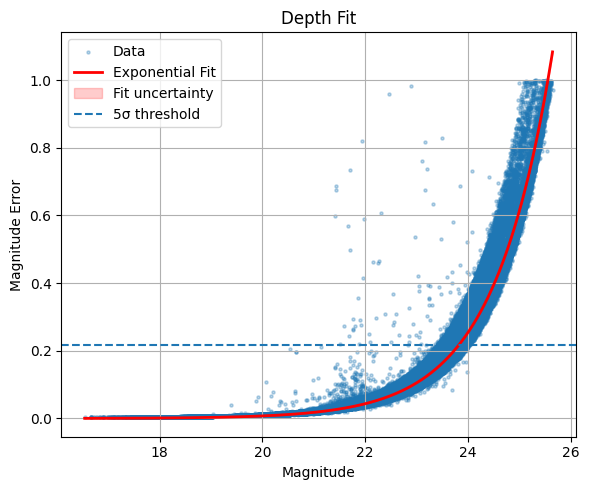

In [41]:
"""
Determining the depth of the DECam images using
an exponential fit to magnitude-error relation.

sigma(m) = a * exp[b (m - M0)]

The 5σ depth is derived from the fitted model.
"""

import pylab as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, brentq


# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------

M0 = 25.0
ZP = 30.354
ZPe = 0.004


# ------------------------------------------------------------
# Exponential fitting
# ------------------------------------------------------------

def exp_func(x, a, b):
    return a * np.exp(b * (x - M0))


def exponential_fit(x_data, y_data, p0, x_min=22, x_max=28):
    """
    Fit exponential relation to magnitude-error data.
    """

    mask = (
        ~np.isnan(x_data) &
        ~np.isnan(y_data) &
        ~np.isinf(x_data) &
        ~np.isinf(y_data)
    )

    x_data_clean = x_data[mask]
    y_data_clean = y_data[mask]

    range_mask = (x_data_clean >= x_min) & (x_data_clean <= x_max)

    x_filtered = x_data_clean[range_mask]
    y_filtered = y_data_clean[range_mask]

    popt, pcov = curve_fit(
        exp_func,
        x_filtered,
        y_filtered,
        p0=p0,
        maxfev=5000
    )

    return popt, pcov, x_filtered, y_filtered


# ------------------------------------------------------------
# SNR conversion
# ------------------------------------------------------------

def calculate_snr(mag_err):
    return (2.5 / np.log(10)) / mag_err


# ------------------------------------------------------------
# Read catalog
# ------------------------------------------------------------

def read_catalog(cat_name):

    colnames = [
        "ID", "X", "Y", "RA", "DEC",
        "MAG_APER", "MAGERR_APER",
        "MAG_AUTO", "MAGERR_AUTO", "FLAGS"
    ]

    df = pd.read_csv(
        cat_name,
        sep=r"\s+",
        comment="#",
        names=colnames
    )

    mag = df["MAG_APER"].values + ZP
    err = np.sqrt(df["MAGERR_APER"].values**2 + ZPe**2)

    good = (
        np.isfinite(mag) &
        np.isfinite(err) &
        (err > 0) &
        (err < 1.0) &
        (mag < 50)
    )

    mag = mag[good]
    err = err[good]

    return mag, err


# ------------------------------------------------------------
# Compute 5σ depth
# ------------------------------------------------------------

def compute_depth(a, b):

    sigma_5 = 1.0857 / 5.0

    def root_func(m):
        return exp_func(m, a, b) - sigma_5

    try:
        depth = brentq(root_func, 22, 28)
    except ValueError:
        depth = np.nan

    return depth


# ------------------------------------------------------------
# Plot depth relation
# ------------------------------------------------------------

def plot_depth(catalog):

    mag, mag_err = read_catalog(catalog)

    # Fit exponential model
    popt, pcov, x, y = exponential_fit(
        mag,
        mag_err,
        p0=[0.05, 0.3]
    )

    a_fit, b_fit = popt
    a_err, b_err = np.sqrt(np.diag(pcov))

    print("\nFit parameters:")
    print(f"a = {a_fit:.6f} ± {a_err:.6f}")
    print(f"b = {b_fit:.6f} ± {b_err:.6f}")

    # Compute SNR
    snr = calculate_snr(mag_err)

    # Compute 5σ depth
    depth = compute_depth(a_fit, b_fit)

    print(f"\n5σ depth = {depth:.2f} mag")

    # Smooth curve
    x_plot = np.linspace(np.min(mag), np.max(mag), 1000)
    y_plot = exp_func(x_plot, *popt)

    # 5σ envelope
    y_upper = exp_func(x_plot, a_fit + 5*a_err, b_fit + 5*b_err)
    y_lower = exp_func(x_plot, a_fit - 5*a_err, b_fit - 5*b_err)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(6,5))

    plt.scatter(mag, mag_err,
                s=5,
                alpha=0.3,
                label="Data")

    plt.plot(x_plot, y_plot,
             lw=2,
             color='red',
             label="Exponential Fit")

    plt.fill_between(x_plot,
                     y_lower,
                     y_upper,
                     alpha=0.2,
                     color='red',
                     label="Fit uncertainty")

    plt.axhline(1.0857/5,
                linestyle='--',
                label="5σ threshold")

    plt.xlabel("Magnitude")
    plt.ylabel("Magnitude Error")
    plt.title("Depth Fit")

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return popt, pcov, depth


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

if __name__ == "__main__":

    INFILE = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_CDFS_depth.cat"

    popt, pcov, depth = plot_depth(INFILE)

Catalog objects: 466130
Magnitude range: 11.774899999999999 26.5373
Objects after cleaning: 466130
Objects used in fit: 200455

Fit parameters:
a = 0.305369 ± 0.000091
b = 0.924129 ± 0.000439

5σ depth = 24.63 mag


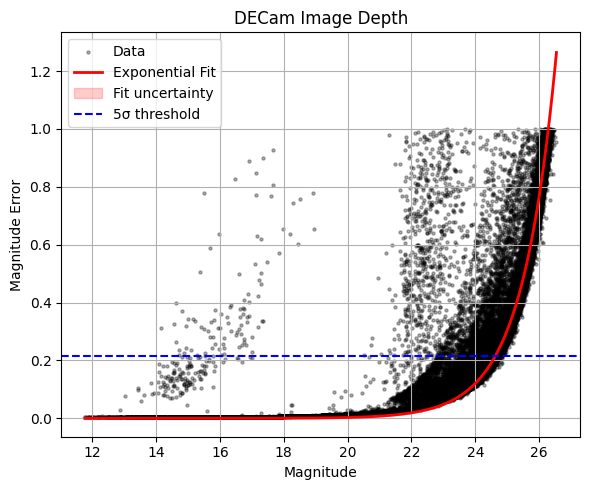


Final 5σ depth = 24.631027092560966


In [45]:
"""
Determining the depth of the DECam images using
an exponential fit to magnitude-error relation.

sigma(m) = a * exp[b (m - M0)]

The 5σ depth is derived from the fitted model.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq


# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------

M0 = 25.0
ZP = 28.3677
ZPe = 0.0029


# ------------------------------------------------------------
# Exponential fitting function
# ------------------------------------------------------------

def exp_func(x, a, b):
    return a * np.exp(b * (x - M0))


# ------------------------------------------------------------
# Exponential fitting routine
# ------------------------------------------------------------

def exponential_fit(x_data, y_data, p0, x_min=22, x_max=28):

    mask = (
        np.isfinite(x_data) &
        np.isfinite(y_data)
    )

    x_data_clean = x_data[mask]
    y_data_clean = y_data[mask]

    range_mask = (x_data_clean >= x_min) & (x_data_clean <= x_max)

    x_filtered = x_data_clean[range_mask]
    y_filtered = y_data_clean[range_mask]

    print("Objects after cleaning:", len(x_data_clean))
    print("Objects used in fit:", len(x_filtered))

    if len(x_filtered) < 10:
        raise ValueError("Not enough points for exponential fit. Check magnitude limits.")

    popt, pcov = curve_fit(
        exp_func,
        x_filtered,
        y_filtered,
        p0=p0,
        maxfev=10000
    )

    return popt, pcov, x_filtered, y_filtered


# ------------------------------------------------------------
# Convert magnitude error to SNR
# ------------------------------------------------------------

def calculate_snr(mag_err):
    return (2.5 / np.log(10)) / mag_err


# ------------------------------------------------------------
# Read SExtractor catalog
# ------------------------------------------------------------

def read_catalog(cat_name):

    colnames = [
        "ID", "X", "Y", "RA", "DEC",
        "MAG_APER", "MAGERR_APER",
        "MAG_AUTO", "MAGERR_AUTO", "FLAGS"
    ]

    df = pd.read_csv(
        cat_name,
        sep=r"\s+",
        comment="#",
        names=colnames
    )

    mag = df["MAG_APER"].values + ZP
    err = np.sqrt(df["MAGERR_APER"].values**2 + ZPe**2)

    good = (
        np.isfinite(mag) &
        np.isfinite(err) &
        (err > 0) &
        (err < 1.0)
    )

    mag = mag[good]
    err = err[good]

    print("Catalog objects:", len(mag))
    print("Magnitude range:", np.min(mag), np.max(mag))

    return mag, err


# ------------------------------------------------------------
# Compute 5σ depth
# ------------------------------------------------------------

def compute_depth(a, b):

    sigma_5 = 1.0857 / 5.0

    def root_func(m):
        return exp_func(m, a, b) - sigma_5

    try:
        depth = brentq(root_func, 20, 35)
    except ValueError:
        depth = np.nan

    return depth


# ------------------------------------------------------------
# Plot depth relation
# ------------------------------------------------------------

def plot_depth(catalog):

    mag, mag_err = read_catalog(catalog)

    # Fit exponential model
    popt, pcov, x_fit, y_fit = exponential_fit(
        mag,
        mag_err,
        p0=[0.05, 0.3],
        x_min=24,
        x_max=30
    )

    a_fit, b_fit = popt
    a_err, b_err = np.sqrt(np.diag(pcov))

    print("\nFit parameters:")
    print(f"a = {a_fit:.6f} ± {a_err:.6f}")
    print(f"b = {b_fit:.6f} ± {b_err:.6f}")

    # Compute SNR
    snr = calculate_snr(mag_err)

    # Compute depth
    depth = compute_depth(a_fit, b_fit)

    print(f"\n5σ depth = {depth:.2f} mag")

    # Smooth fit curve
    x_plot = np.linspace(np.min(mag), np.max(mag), 1000)
    y_plot = exp_func(x_plot, *popt)

    # Uncertainty envelope
    y_upper = exp_func(x_plot, a_fit + 5*a_err, b_fit + 5*b_err)
    y_lower = exp_func(x_plot, a_fit - 5*a_err, b_fit - 5*b_err)

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------

    plt.figure(figsize=(6,5))

    plt.scatter(
        mag,
        mag_err,
        s=5,
        alpha=0.3,
        color="black",
        label="Data"
    )

    plt.plot(
        x_plot,
        y_plot,
        lw=2,
        color="red",
        label="Exponential Fit"
    )

    plt.fill_between(
        x_plot,
        y_lower,
        y_upper,
        alpha=0.2,
        color="red",
        label="Fit uncertainty"
    )

    sigma_5 = 1.0857/5

    plt.axhline(
        sigma_5,
        linestyle='--',
        color='blue',
        label='5σ threshold'
    )

    plt.xlabel("Magnitude")
    plt.ylabel("Magnitude Error")
    plt.title("DECam Image Depth")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return popt, pcov, depth


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

if __name__ == "__main__":

    INFILE = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/y_band_depth.cat"

    popt, pcov, depth = plot_depth(INFILE)

    print("\nFinal 5σ depth =", depth)

Objects used for fit: 714911

Fit parameters:
a = 0.052837 ± 0.000013
b = 0.854309 ± 0.000162

5σ depth = 26.65 mag

Degraded catalog saved as: /Users/aishwarya/Desktop/new_cdfs/cat/degraded_Z_catalog.cat


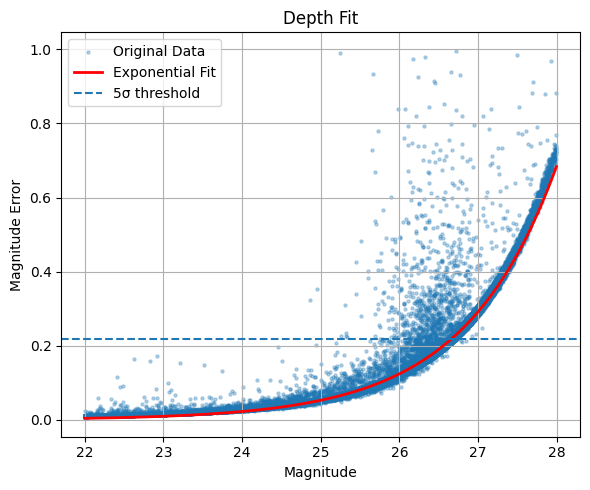

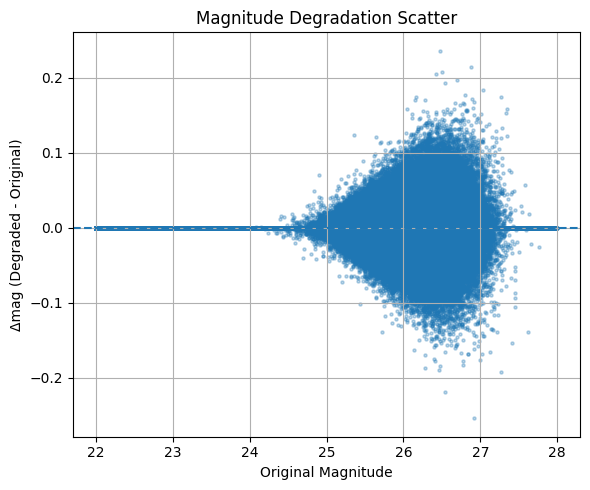

In [13]:
"""
Module for:
1) Fitting exponential to magnitude-error data
2) Computing 5σ depth
3) Degrading magnitudes to simulate shallower depth

Model:
    sigma(m) = a * exp[b (m - M0)]
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit, brentq

# ============================================================
# Constants
# ============================================================

M0 = 25.0
ZP = 31.524
ZPe = 0.004

np.random.seed(42)  # for reproducibility

# ============================================================
# S/N conversion
# ============================================================

def calculate_snr(mag_err):
    return (2.5 / np.log(10)) / mag_err


# ============================================================
# Exponential model
# ============================================================

def exponential_func(m, a, b):
    return a * np.exp(b * (m - M0))


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":

    infile = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Z_CDFS_depth.cat"

    colnames = ["ID", "X", "Y", "RA", "DEC",
                "MAG_APER", "MAGERR_APER",
                "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

    df = pd.read_csv(infile, sep=r"\s+", comment="#", names=colnames)

    # --------------------------------------------------------
    # Zeropoint correction
    # --------------------------------------------------------

    mag_all = df["MAG_APER"].values + ZP
    err_all = np.sqrt(df["MAGERR_APER"].values**2 + ZPe**2)

    # --------------------------------------------------------
    # Cleaning
    # --------------------------------------------------------

    valid_mask = (
        np.isfinite(mag_all) &
        np.isfinite(err_all) &
        (err_all > 0) &
        (err_all < 1.0) &
        (mag_all > 22) &
        (mag_all < 28)
    )

    mag = mag_all[valid_mask]
    err = err_all[valid_mask]

    # Sort
    sort_idx = np.argsort(mag)
    mag = mag[sort_idx]
    err = err[sort_idx]

    print(f"Objects used for fit: {len(mag)}")

    # ========================================================
    # 1) FIT EXPONENTIAL DEPTH MODEL
    # ========================================================

    params, cov_matrix = curve_fit(
        exponential_func,
        xdata=mag,
        ydata=err,
        p0=(0.05, 0.3)
    )

    a_fit, b_fit = params
    a_err, b_err = np.sqrt(np.diag(cov_matrix))

    print("\nFit parameters:")
    print(f"a = {a_fit:.6f} ± {a_err:.6f}")
    print(f"b = {b_fit:.6f} ± {b_err:.6f}")

    # ========================================================
    # 2) COMPUTE 5σ DEPTH
    # ========================================================

    sigma_5 = 1.0857 / 5.0

    def root_func(m):
        return exponential_func(m, a_fit, b_fit) - sigma_5

    try:
        depth_5sigma = brentq(root_func, 22, 28)
        print(f"\n5σ depth = {depth_5sigma:.2f} mag")
    except ValueError:
        depth_5sigma = np.nan
        print("\n5σ depth not found in range.")

    # ========================================================
    # 3) COMPUTE DEGRADED ERRORS
    # ========================================================

    sigma_degraded = exponential_func(mag, a_fit, b_fit)

    # Extra noise required
    sigma_extra = np.sqrt(
        np.maximum(sigma_degraded**2 - err**2, 0)
    )

    # ========================================================
    # 4) GENERATE DEGRADED MAGNITUDES
    # ========================================================

    mag_degraded = np.random.normal(
        loc=mag,
        scale=sigma_extra
    )

    # ========================================================
    # 5) SAVE NEW CATALOG
    # ========================================================

    df_clean = df[valid_mask].iloc[sort_idx].copy()

    df_clean["MAG_DEGRADED"] = mag_degraded
    df_clean["MAGERR_DEGRADED"] = sigma_degraded

    outfile = "/Users/aishwarya/Desktop/new_cdfs/cat/degraded_Z_catalog.cat"
    df_clean.to_csv(outfile, sep=" ", index=False)

    print(f"\nDegraded catalog saved as: {outfile}")

    # ========================================================
    # 6) PLOTS
    # ========================================================

    x_finer = np.linspace(mag.min(), mag.max(), 1000)
    y_fitted = exponential_func(x_finer, a_fit, b_fit)

    plt.figure(figsize=(6, 5))

    plt.scatter(mag, err, s=5, alpha=0.3, label="Original Data")
    plt.plot(x_finer, y_fitted, color='red', linewidth=2,
             label="Exponential Fit")

    plt.axhline(sigma_5, linestyle='--', label='5σ threshold')

    plt.xlabel("Magnitude")
    plt.ylabel("Magnitude Error")
    plt.title("Depth Fit")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Diagnostic: Original vs Degraded Magnitudes
    # --------------------------------------------------------

    plt.figure(figsize=(6, 5))
    plt.scatter(mag, mag_degraded - mag,
                s=5, alpha=0.3)

    plt.axhline(0, linestyle='--')
    plt.xlabel("Original Magnitude")
    plt.ylabel("Δmag (Degraded - Original)")
    plt.title("Magnitude Degradation Scatter")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Trial


i-band fit parameters:
a, b, c = [1.00000000e-12 9.51435559e-01 3.49901434e-12]


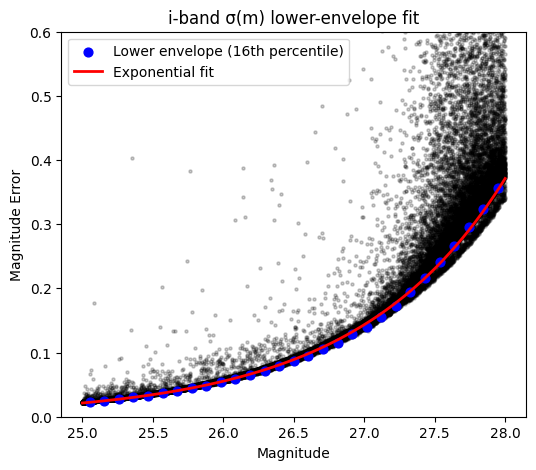

i-band 5σ depth = 27.44

z-band fit parameters:
a, b, c = [2.07757167e-12 9.33653566e-01 1.68059310e-04]


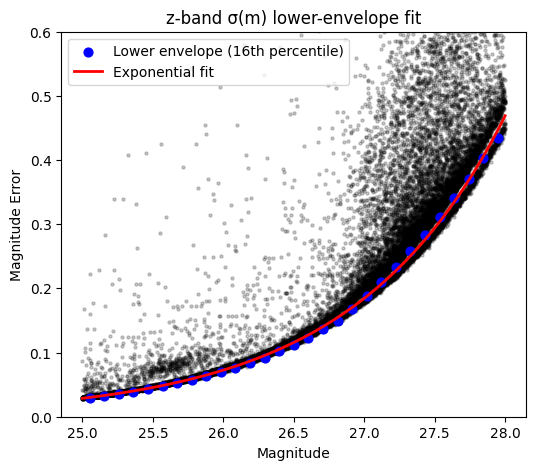

z-band 5σ depth = 27.17

Final 5σ depths:
i: 27.436268533886363
z: 27.17481990147024


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq
from astropy.coordinates import SkyCoord
import astropy.units as u

# ============================================================
# File paths
# ============================================================
i_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_I_CDFS.cat"
z_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_Z_CDFS.cat"
y_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_Y_CDFS.cat"

# ============================================================
# Load catalogs
# ============================================================
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)

# ============================================================
# Zero points
# ============================================================
ZP_i, ZP_z, ZP_y = 31.354, 31.524, 30.3382
zp_err_i, zp_err_z, zp_err_y = 0.004, 0.004, 0.009

for df, zp, zp_err in zip(
        [i_df, z_df, y_df],
        [ZP_i, ZP_z, ZP_y],
        [zp_err_i, zp_err_z, zp_err_y]):

    df["MAG_APER_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_APER_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zp_err**2)

# ============================================================
# Cross-match to align catalogs
# ============================================================
y_coords = SkyCoord(y_df.RA.values*u.deg, y_df.DEC.values*u.deg)
z_coords = SkyCoord(z_df.RA.values*u.deg, z_df.DEC.values*u.deg)
i_coords = SkyCoord(i_df.RA.values*u.deg, i_df.DEC.values*u.deg)

idx_z, sep_z, _ = y_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = y_coords.match_to_catalog_sky(i_coords)

match_radius = 1.0  # arcsec
z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

def align_mag_err(n, df, idx, mask):
    mag = np.full(n, np.nan)
    err = np.full(n, np.nan)
    mag[mask] = df.MAG_APER_CAL.values[idx[mask]]
    err[mask] = df.MAGERR_APER_CAL.values[idx[mask]]
    return mag, err

y_mag = y_df.MAG_APER_CAL.values
y_err = y_df.MAGERR_APER_CAL.values

z_mag, z_err = align_mag_err(len(y_mag), z_df, idx_z, z_match)
i_mag, i_err = align_mag_err(len(y_mag), i_df, idx_i, i_match)

# ============================================================
# Common mask
# ============================================================
mask = (~np.isnan(y_mag)) & (~np.isnan(z_mag)) & (~np.isnan(i_mag))

y_mag, y_err = y_mag[mask], y_err[mask]
z_mag, z_err = z_mag[mask], z_err[mask]
i_mag, i_err = i_mag[mask], i_err[mask]

# ============================================================
# Exponential sigma model
# ============================================================
def sigma_model(m, a, b, c):
    exponent = np.clip(b * m, -100, 100)
    return a * np.exp(exponent) + c

# ============================================================
# Correct lower-envelope fitting function
# ============================================================
def fit_sigma_exponential(mag, err, bandname):

    # Clean data
    valid = np.isfinite(mag) & np.isfinite(err)
    mag = mag[valid]
    err = err[valid]

    # Restrict to faint regime
    mask_range = (mag > 25) & (mag < 28)
    mag = mag[mask_range]
    err = err[mask_range]

    # ========================================================
    # BIN IN MAGNITUDE AND TAKE LOWER PERCENTILE
    # ========================================================
    bins = np.linspace(25, 28, 30)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    sigma_floor = []

    for i in range(len(bins)-1):
        in_bin = (mag >= bins[i]) & (mag < bins[i+1])
        if np.sum(in_bin) > 20:
            # 16th percentile traces lower envelope
            sigma_floor.append(np.percentile(err[in_bin], 16))
        else:
            sigma_floor.append(np.nan)

    sigma_floor = np.array(sigma_floor)
    good = np.isfinite(sigma_floor)

    mag_fit = bin_centers[good]
    err_fit = sigma_floor[good]

    # ========================================================
    # Fit exponential to lower envelope
    # ========================================================
    p0 = [1e-7, 0.45, 0.001]
    bounds = ([1e-12, 0.0, 0.0],
              [1e-2,   2.0,  0.1])

    popt, pcov = curve_fit(
        sigma_model,
        mag_fit,
        err_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000
    )

    print(f"\n{bandname} fit parameters:")
    print("a, b, c =", popt)

    # ========================================================
    # Plot
    # ========================================================
    x_fine = np.linspace(25, 28, 1000)
    y_fit = sigma_model(x_fine, *popt)

    plt.figure(figsize=(6,5))
    plt.scatter(mag, err, s=5, alpha=0.2, color='black')
    plt.scatter(mag_fit, err_fit, color='blue', s=40,
                label='Lower envelope (16th percentile)')
    plt.plot(x_fine, y_fit, color='red', lw=2, label='Exponential fit')
    plt.xlabel("Magnitude")
    plt.ylabel("Magnitude Error")
    plt.title(f"{bandname} σ(m) lower-envelope fit")
    plt.ylim(0,0.6)
    plt.legend()
    plt.show()

    # ========================================================
    # Compute 5σ depth
    # ========================================================
    sigma_5 = 2.5 / (np.log(10) * 5)

    def root_func(m):
        return sigma_model(m, *popt) - sigma_5

    m_5sigma = brentq(root_func, 20, 30)

    print(f"{bandname} 5σ depth = {m_5sigma:.2f}")

    return popt, m_5sigma

# ============================================================
# Run fits
# ============================================================

popt_i, lim_i = fit_sigma_exponential(i_mag, i_err, "i-band")
popt_z, lim_z = fit_sigma_exponential(z_mag, z_err, "z-band")

print("\nFinal 5σ depths:")

print("i:", lim_i)
print("z:", lim_z)

In [36]:
# ============================================================
# Degrade i- and z-band magnitudes (FULL CATALOG VERSION)
# ============================================================

def degrade_band_full(original_df, mag_cal, err_cal, popt, bandname, output_path):
    """
    Degrade magnitudes using fitted sigma(m) model.
    Preserves full original catalog structure.
    """

    print(f"\nDegrading {bandname}...")

    # Copy full original dataframe
    degraded_df = original_df.copy().reset_index(drop=True)

    # Compute degraded sigma from fitted model
    sigma_degraded = sigma_model(mag_cal, *popt)

    # Compute additional scatter required
    sigma_extra_sq = sigma_degraded**2 - err_cal**2
    sigma_extra_sq[sigma_extra_sq < 0] = 0.0
    sigma_extra = np.sqrt(sigma_extra_sq)

    # Draw degraded magnitudes (CALIBRATED SPACE)
    mag_cal_degraded = np.random.normal(loc=mag_cal, scale=sigma_extra)

    # Convert back to instrumental MAG_APER
    # MAG_CAL = MAG_APER + ZP  →  MAG_APER = MAG_CAL - ZP
    if bandname == "i-band":
        ZP_use = ZP_i
        zp_err_use = zp_err_i
    elif bandname == "z-band":
        ZP_use = ZP_z
        zp_err_use = zp_err_z
    else:
        raise ValueError("Only i and z supported here.")

    mag_aper_degraded = mag_cal_degraded - ZP_use

    # Update dataframe columns
    degraded_df["MAG_APER"] = mag_aper_degraded
    degraded_df["MAGERR_APER"] = np.sqrt(
        sigma_degraded**2 - zp_err_use**2
    )

    # Save in EXACT same format as original
    degraded_df.to_csv(
        output_path,
        sep=" ",
        index=False,
        header=False   # important: match original format
    )

    print(f"{bandname} degraded catalog saved to:")
    print(output_path)

    return degraded_df

In [37]:
z_output = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/z_band_degraded.cat"
i_output = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/i_band_degraded.cat"

z_degraded_df = degrade_band_full(
    z_df,
    z_df["MAG_APER_CAL"].values,
    z_df["MAGERR_APER_CAL"].values,
    popt_z,
    "z-band",
    z_output
)

i_degraded_df = degrade_band_full(
    i_df,
    i_df["MAG_APER_CAL"].values,
    i_df["MAGERR_APER_CAL"].values,
    popt_i,
    "i-band",
    i_output
)


print("\nDegradation complete for i and z bands.")


Degrading z-band...


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_67351/3975238790.py:42: RuntimeWarning: invalid value encountered in sqrt
  degraded_df["MAGERR_APER"] = np.sqrt(


z-band degraded catalog saved to:
/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/z_band_degraded.cat

Degrading i-band...
i-band degraded catalog saved to:
/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/i_band_degraded.cat

Degradation complete for i and z bands.


In [46]:
from astropy.io import fits
import numpy as np

data = fits.getdata("/Users/aishwarya/Desktop/new_cdfs/trimmed_2deg/trim2deg_i_wgt.fits")

print("Min:", np.nanmin(data))
print("Max:", np.nanmax(data))
print("Mean:", np.nanmean(data))

Min: -0.0257907
Max: 0.5087822
Mean: 0.27682948
